## Carbon Credit Auction Clearing Via Probablistic Computing

Dataset used:
emission-spot-primary-market-auction-report-2025-data.xlsx
<br>
Downloaded directly from the EEX EUA website [Here](https://www.eex.com/en/market-data/market-data-hub/environmentals/eex-eua-primary-auction-spot-download)


In [24]:
# Setup
! pip install dimod dwave-neal numpy pandas openpyxl matplotlib pulp


Defaulting to user installation because normal site-packages is not writeable


- `dimod` + `dwave-neal`: QUBO construction and SA solver for benchmarking
- `numpy` + `pandas`: data handling and the EEX xlsx
- `openpyxl`: reading the `.xlsx` file with pandas
- `matplotlib`: plots for the notebook
- `pulp`: IP baseline solver

In [25]:
# Quick sanity check to confirm all the imports
import dimod
import neal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

print("dimod:", dimod.__version__)
print("neal:", neal.__version__)
print("pulp:", pulp.__version__)
print(pulp.listSolvers(onlyAvailable=True))
# Should show ['PULP_CBC_CMD'] at minimum

# --------------sanity check for neal solver------------------
bqm = dimod.BinaryQuadraticModel(vartype='BINARY')
bqm.add_variable('x0', -1.0)  # wants to be 1
bqm.add_variable('x1', -1.0)  # wants to be 1
bqm.add_interaction('x0', 'x1', 3.0)  # but penalises both being 1
# E=−x0​−x1​+3x0​x1​ is the model

sampler = neal.SimulatedAnnealingSampler()
result = sampler.sample(bqm, num_reads=100)
print("\nBest sample:", result.first.sample)
print("Energy:", result.first.energy)
# Should give x0=1, x1=0 (or x1=1, x0=0) with energy -1.0

dimod: 0.12.22
neal: 0.6.0
pulp: 3.3.2
['PULP_CBC_CMD']

Best sample: {'x0': np.int8(0), 'x1': np.int8(1)}
Energy: -1.0


## Cell 1: Data Loading and Cleaning

Load the raw EEX auction report and keep only the columns relevant
to the QUBO formulation. Everything else (country distribution columns,
administrative fields) is dropped.

### What each kept column is used for
| Column | Role in model |
|--------|---------------|
| `date` | Session identifier, used for multi-session sampling |
| `auction_type` | Credit type τ determines which supply cap applies |
| `clearing_price` | Peak of triangular bid price distribution |
| `min_bid`, `max_bid` | Bounds of triangular bid price distribution |
| `mean_bid`, `median_bid` | Sanity check on price reconstruction |
| `supply` | S_τ hard supply cap per type, goes into H_cap |
| `n_bids` | How many synthetic bids to generate per session |
| `n_successful` | Ground truth: how many bids actually cleared |
| `avg_bid_size` | Mean of Pareto bid quantity distribution |
| `std_bid_volume` | Spread of Pareto bid quantity distribution |
| `cover_ratio` | Demand/supply ratio used to rescale bid quantities |
| `n_bidders`, `n_successful_bidders` | Sanity check on reconstruction |

### Auction type mapping
Raw EEX session names are verbose strings. Mapped to clean labels:
- `Auction 4. Period CAP3 EU`  → `EUA`
- `Auction 4. Period DE`       → `EUA_DE`  
- `Auction 4. Period CAP3 PL`  → `EUA_PL`
- `Auction 4. Period CAP3 NIR` → `EUAA`

### Output
Clean dataframe (`df`) with 213 rows (sessions) × 20 columns,
date range 2025-01-07 to 2025-12-15.

In [26]:

# Load
df_raw = pd.read_excel('emission-spot-primary-market-auction-report-2025-data.xlsx', header=5)
df_raw = df_raw.dropna(subset=['Date'])

# Keep only useful columns
keep = {
    'Date': 'date',
    'Auction Name': 'auction_type',
    'Auction Price €/tCO2': 'clearing_price',
    'Minimum Bid €/tCO2': 'min_bid',
    'Maximum Bid €/tCO2': 'max_bid',
    'Mean €/tCO2': 'mean_bid',
    'Median €/tCO2': 'median_bid',
    'Auction Volume tCO2': 'supply',
    'Number of bids submitted': 'n_bids',
    'Number of successful bids': 'n_successful',
    'Average bid size': 'avg_bid_size',
    'Standard deviation of bid volume per bidder': 'std_bid_volume',
    'Cover Ratio': 'cover_ratio',
    'Total Number of Bidders': 'n_bidders',
    'Number of Successful Bidders': 'n_successful_bidders',
    'Innovation Fund\n(IF)': 'fund_IF',
    'InnoFund RRF\n(IX)': 'fund_IX',
    'Modernisation Fund\n(MF)': 'fund_MF',
    'MS RRF\n(MX)': 'fund_MX',
    'Social Climate Fund\n(SF)': 'fund_SF',
}

df = df_raw[list(keep.keys())].rename(columns=keep).copy()
df['date'] = pd.to_datetime(df['date'])

# auction type labels
type_map = {
    'Auction 4. Period CAP3 EU': 'EUA',
    'Auction 4. Period DE': 'EUA_DE',
    'Auction 4. Period CAP3 PL': 'EUA_PL',
    'Auction 4. Period CAP3 NIR': 'EUAA',
}
df['auction_type'] = df['auction_type'].map(type_map).fillna(df['auction_type'])

# Summary per type
print(df.groupby('auction_type')[['clearing_price','supply','n_bids','cover_ratio','avg_bid_size','std_bid_volume']].mean().round(2))
print(f"\nTotal sessions: {len(df)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

print(df_raw['Auction Name'].value_counts())
print(f"\nTotal: {df_raw['Auction Name'].nunique()} unique types")

print(df)

              clearing_price      supply  n_bids  cover_ratio  avg_bid_size  \
auction_type                                                                  
EUA                    73.36  3252834.51   98.77         1.54      51159.30   
EUAA                   77.39   796500.00   49.00         1.65      26776.00   
EUA_DE                 73.78  1633411.11   86.64         2.06      39002.20   
EUA_PL                 73.25  2101300.00   94.08         1.79      40223.88   

              std_bid_volume  
auction_type                  
EUA                258434.39  
EUAA                70230.00  
EUA_DE             171873.29  
EUA_PL             184609.36  

Total sessions: 213
Date range: 2025-01-07 to 2025-12-15
Auction Name
Auction 4. Period CAP3 EU     142
Auction 4. Period DE           45
Auction 4. Period CAP3 PL      25
Auction 4. Period CAP3 NIR      1
Name: count, dtype: int64

Total: 4 unique types
          date auction_type  clearing_price  min_bid  max_bid  mean_bid  \
0   2025

/home/username/Desktop/Python/QUBO/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## Cell 2: Bid Reconstruction

### Data Limitations
While data for all conducted auctions is publicly available, the exact
bid submitted by each party is not public individual bid data is
confidential under EU ETS regulations. We solve this by reconstructing
a synthetic bid population whose statistical properties match the
published session aggregates exactly. This is standard practice in
computational economics when microdata is confidential.

### Session Selection
One median session per auction type is selected as the representative
instance. The median session (middle row by date) is chosen over the
first or last session to avoid January thin-market anomalies or
year-end effects.

### Bid Quantity Distribution
Each bid quantity q_i is drawn from a **Lognormal distribution**
parameterised directly from the real session statistics.

### Bid Price Distribution
Each bid price p_i is drawn from a **triangular distribution**:
```
p_i ~ Triangular(min_bid, clearing_price, max_bid)
```
All three parameters come directly from the real session data.
Zero free parameters the distribution is fully determined by
published statistics.

### Cover Ratio Rescaling
After reconstruction, total bid volume is rescaled to match the
real session cover ratio:
```
cover_ratio = total_bid_volume / supply

quantities *= real_cover_ratio / reconstructed_cover_ratio
```
This ensures the supply constraint is genuinely binding without
rescaling, reconstructed bids may fall below supply and the
optimisation problem becomes trivially easy (accept everything).

Real cover ratios example from 2025 data:
```
EUA:    1.54  (demand 54% above supply)
EUA_DE: 2.06  
EUA_PL: 1.79  
EUAA:   1.65  
```

### Bid Value
Total value of bid i in euros:
```
v_i = q_i × p_i
```
This is the welfare term in H_obj. Accepting bid i contributes v_i
to total welfare.

### Package Bid Modelling (EUAA/EUA Linking)
EUAA allowances cover aviation emissions only. Aviation operators
also hold EUA bids for their non-aviation installations (ground
operations, facilities). A single operator needing both types
values them jointly more than separately this is a
**complementary valuation**.

We model this by linking 30% of EUAA bidders to random EUA bidders
as package pairs. The synergy premium w_ik is set to 15% of the
smaller bid's value:
```
w_ik = 0.15 × min(v_i, v_k)
```
Accepting both bids together yields an additional bonus w_ik beyond
their individual values. This creates quadratic coupling between
bid variables the problem is no longer separable and cannot be
solved by greedy price-sorting alone.

This is encoded in H_pkg as an off-diagonal attractive coupling:
```
H_pkg = -A × Σ_{(i,k) ∈ packages} w_ik × x_i × x_k
```

The integer programming linearisation uses auxiliary variables z_ik:
```
z_ik ≤ x_i
z_ik ≤ x_k  
z_ik ≥ x_i + x_k - 1
```
z_ik = 1 only when both x_i = x_k = 1, capturing the joint bonus
exactly without introducing non-linearity into the IP formulation.

In [27]:
def reconstruct_bids_multisession(sessions, package_fraction=0.3, seed=42):   
    rng = np.random.default_rng(seed)
    all_bids = []

    for tau, session in sessions.items():
        n       = int(session['n_bids'])
        mu_q    = session['avg_bid_size']
        sigma_q = session['std_bid_volume']
        p_clear = session['clearing_price']
        p_min   = session['min_bid']
        p_max   = session['max_bid']
        supply  = session['supply']

        #log-normal from real mean and std (not used)
        var   = sigma_q**2
        mu_ln = np.log(mu_q**2 / np.sqrt(var + mu_q**2))
        sg_ln = np.sqrt(np.log(1 + var / mu_q**2))
        quantities = rng.lognormal(mu_ln, sg_ln, n)
        
    

        # triangular between real min/max, peak at clearing price
        prices = rng.triangular(p_min, p_clear, p_max, n)

        bids = pd.DataFrame({
            'quantity': quantities,
            'price':    prices,
            'value':    quantities * prices,
            'type':     tau,
            'supply':   supply,
            'package_partner': -1,   # -1 means no package link
            'package_bonus':    0.0,
        })

        # Force cover ratio to match real session
        real_cover    = session['cover_ratio']
        current_cover = bids['quantity'].sum() / supply
        bids['quantity'] *= (real_cover / current_cover)
        bids['value']     = bids['quantity'] * bids['price']

        all_bids.append(bids)

    # Concatenate all sessions into one bid pool
    combined = pd.concat(all_bids, ignore_index=True)

    # --- Package bid linking ---
    euaa_idx = combined[combined['type'] == 'EUAA'].index.tolist()
    eua_idx  = combined[combined['type'] == 'EUA'].index.tolist()

    n_packages = int(len(euaa_idx) * package_fraction)
    # Pick random EUAA bids as package participants
    euaa_partners = rng.choice(euaa_idx, size=n_packages, replace=False)
    # Match each to a random EUA bid
    eua_partners  = rng.choice(eua_idx,  size=n_packages, replace=False)

    for euaa_i, eua_k in zip(euaa_partners, eua_partners):
        w = 0.15 * min(combined.loc[euaa_i, 'value'],
                       combined.loc[eua_k,  'value'])
        combined.loc[euaa_i, 'package_partner'] = eua_k
        combined.loc[eua_k,  'package_partner'] = euaa_i
        combined.loc[euaa_i, 'package_bonus']   = w
        combined.loc[eua_k,  'package_bonus']   = w

    return combined

sessions = {
    tau: df[df['auction_type'] == tau].iloc[len(df[df['auction_type'] == tau])//2]
    for tau in ['EUA', 'EUA_DE', 'EUA_PL', 'EUAA']
}

# Build multi-session bid pool
all_bids = reconstruct_bids_multisession(sessions)

print(f"Total bids: {len(all_bids)}")
print(all_bids.groupby('type')[['quantity','value','supply']].agg({
    'quantity': ['mean','sum'],
    'value':    'mean',
    'supply':   'first'
}).round(0))
print(f"\nPackage pairs: {(all_bids['package_partner'] != -1).sum() // 2}")
print(f"Avg package bonus: €{all_bids[all_bids['package_bonus']>0]['package_bonus'].mean():,.0f}")

Total bids: 321
       quantity                 value   supply
           mean        sum       mean    first
type                                          
EUA     45112.0  4511245.0  3263908.0  3245500
EUAA    26821.0  1314225.0  1930094.0   796500
EUA_DE  38925.0  3503260.0  3438688.0  1607000
EUA_PL  43472.0  3564700.0  3792499.0  2072500

Package pairs: 14
Avg package bonus: €117,031


## Cell 3: QUBO Construction

The goal is to convert the auction clearing problem into a single
matrix Q such that finding the binary vector x that minimises
x^T Q x gives the optimal allocation.

### Normalisation (done inside build_qubo)

Raw bid quantities are in tCO2 (tens of thousands) and values are
in euros (millions). These scales make the penalty coefficients
astronomically large and numerically unstable. We normalise per
auction type before building Q:

```
quantity /= S_tau        # q_i is now fraction of supply, 0 to ~0.3
value    /= v_max_tau    # v_i is now 0 to 1
```

Normalising per type independently is important EUA supply is
3.2M tCO2 and EUAA supply is 796k tCO2. If we used a global scale
both types would end up at different effective scales, making the
penalty work correctly for one type but not the other.

### Penalty coefficient $C$

$C$ controls how strongly the supply constraint is enforced. It must be large enough that violating the supply cap costs more energy than the welfare gained from an extra.

The standard mean-field dominance condition fails when individual bids are drawn from a heavy-tailed Pareto distribution, as outlier bids can significantly alter the effective off-diagonal pushback[cite: 3]. To prevent constraint violation in the raw QUBO space, the dominance condition must overcome the combined reward of the maximum normalized value ($v_{\max}$), the maximum package synergy bonus ($w_{\max}$), and a baseline safety margin, scaled by the worst-case single bid quantity ($q_{\max}$):

Instead of a strict barrier, we set `C_mult = 10.0`. This softens the final per-type penalty coefficient:

### Why a Relaxed $C_{\text{mult}} = 10$ Optimizes Post-Processing Heuristics

Using a softer penalty multiplier ($C_{\text{mult}} = 10$ instead of $100$) is an intentional design choice to optimize the performance of our hybrid classical post-processing repair pipeline:

*   **Mitigating Landscape Stiffness:** High penalty terms flatten out the objective function's signal and create massive, artificial energy barriers. A multiplier of 10 lowers these barriers, preventing the stochastic search from freezing prematurely in poor local minima far below the supply cap.
*   **Maximizing Post-Repair Yield:** The classical post-processing step functions by sorting accepted bids by value-density and pruning the least efficient allocations until feasibility is achieved. By letting the solver generate a high-volume, high-quality candidate pool, the classical repair engine has a superior selection of bids to trim down, ultimately capturing a higher percentage of the global IP optimal welfare than a strictly constrained run.


### H_obj Welfare objective

```
Q[i,i] -= A * v_i
```

Negative diagonal entry for each bid. SA minimises energy, so a
negative diagonal rewards setting x_i = 1 (accepting the bid).
Larger v_i = stronger pull toward acceptance = higher welfare bids
are preferred. This is the objective we are maximising.

### H_pkg Package bid bonus

```
Q[i,k] -= A * w_ik    (for package pairs only)
```

Negative off-diagonal entry between package partners i and k.
SA minimises energy, so a negative off-diagonal rewards setting
both x_i = 1 and x_k = 1 simultaneously. This creates an
attractive coupling — the optimizer is incentivised to accept
both members of a package pair together.

w_ik is the synergy bonus (15% of smaller bid value), normalised
by v_max. This term is what makes the problem genuinely beyond
a simple knapsack — bid decisions are no longer independent.

### H_cap Supply constraint

```
Q[i,i] += C * q_i² - 2 * C * S * q_i     (diagonal)
Q[i,k] += 2 * C * q_i * q_k              (off-diagonal, same type)
```

This comes from expanding C * (Σ q_i x_i - S)²:

```
C * (Σ q_i x_i - S)²
= C * Σ q_i² x_i          → diagonal positive terms
+ 2C * Σ_{i<k} q_i q_k x_i x_k  → off-diagonal positive terms
- 2C * S * Σ q_i x_i      → diagonal negative terms
+ C * S²                  → constant, ignored
```

The diagonal term per bid is net negative (C*q² - 2*C*S*q < 0
when q < 2S, always true here). This means individually each bid
looks rewarding to accept. The constraint is enforced by the
off-diagonal terms as more bids from the same type are accepted,
the accumulated pairwise penalties push the energy up until
accepting another bid costs more than it gains.

This is why C must be large the off-diagonal terms need to
accumulate enough pushback across ~160 accepted bids to overcome
the negative diagonal pull of each individual bid.

### QUBO structure summary

```
Shape:         321 × 321  (one variable per reconstructed bid)
Diagonal:      H_obj + H_cap diagonal terms per bid
Off-diagonal:  H_pkg (package pairs) + H_cap (same-type pairs)
Nonzeros:      ~50,000 off-diagonal entries
```

The ground state of x^T Q x corresponds to the optimal feasible
allocation. SA finds an approximation to this ground state via
stochastic spin-flip dynamics.

In [28]:
def build_qubo(bids, A=1.0, C_mult=10.0):
    bids = bids.reset_index(drop=True).copy()
    n = len(bids)
    supply_buffer_margin = 0

    for col in ['quantity', 'value', 'supply', 'package_bonus']:
        bids[col] = bids[col].astype(float)

    S_tau     = bids.groupby('type')['supply'].transform('first')
    v_max_tau = bids.groupby('type')['value'].transform('max')

    bids['quantity']      = bids['quantity'] / S_tau
    bids['supply']        = 1 - supply_buffer_margin
    bids['value']         = bids['value'] / v_max_tau
    bids['package_bonus'] = bids['package_bonus'] / v_max_tau

    v = bids['value'].to_numpy()
    q = bids['quantity'].to_numpy()
    types = bids['type'].to_numpy()

    w_max = bids['package_bonus'].max()

    Q = np.zeros((n, n))
    Q[np.diag_indices(n)] -= A * v

    partner = bids['package_partner'].to_numpy().astype(int)
    has_partner = (partner != -1) & (partner > np.arange(n))
    i_idx = np.where(has_partner)[0]
    k_idx = partner[i_idx]
    Q[i_idx, k_idx] -= A * bids['package_bonus'].to_numpy()[i_idx]

    C_per_type = {}
    for tau in bids['type'].unique():
        idx = np.where(types == tau)[0]
        q_t = q[idx]
        v_t = v[idx]
        S_t = bids.loc[idx[0], 'supply']

        # per-type dominance: use THIS type's own v_max, q_mean, q_max
        # use q_max (worst case) for the denominator.
        # since the outlier bid is the one most likely to break feasibility
        C_tau = C_mult * (v_t.max() + w_max + 1.0) / (2 * q_t.max())
        C_per_type[tau] = C_tau

        Q[idx, idx] += C_tau * q_t**2 - 2 * C_tau * S_t * q_t
        outer = 2 * C_tau * np.outer(q_t, q_t)
        iu, ku = np.triu_indices(len(idx), k=1)
        Q[idx[iu], idx[ku]] += outer[iu, ku]

    print("Per-type C:", {k: round(v_, 2) for k, v_ in C_per_type.items()})

    return Q, {
        'A': A, 'C_per_type': C_per_type, 'C_mult': C_mult,
        'n_bids': n,
        'n_packages': int((bids['package_partner'] != -1).sum() // 2),
    }


## Cell 4: Solvers

### solve_sa
Takes Q (QUBO matrix), normalized bids, and raw bids.

- **bids_norm** feasibility check in normalized space (supply=1.0)
- **bids_raw** welfare reported in real euros

Loads Q into dimod BQM, runs neal SA with num_reads independent
runs each doing num_sweeps spin flips under geometric cooling.
Best solution across all reads is returned.

Feasibility: checks normalized volume ≤ 1.0 per type after solving.
Welfare: summed from raw bid values for real euro reporting.

### solve_ip
Runs on raw bids only IP handles constraints natively, no
normalization needed.

Maximises Σ v_i x_i + package bonuses subject to Σ q_i x_i ≤ S
per type. Package bonus x_i × x_k is nonlinear so linearised via
auxiliary variable z_ik:

Solved exactly by CBC.
IP result is the baseline result provably optimal feasible solution.


### Normalization block
all_bids_norm mirrors all_bids with quantities divided by S_tau
and values divided by v_max per type. Supply set to 1.0.
all_bids stays untouched for IP and welfare reporting.


In [29]:
def solve_sa(Q, bids_norm, bids_raw, num_reads=200, num_sweeps=1000):
    """
    Q         — QUBO matrix built from normalized bids
    bids_norm — normalized bids, used for feasibility check
    bids_raw  — raw bids in real euros/tCO2, used for welfare reporting
    """
    bids_norm = bids_norm.reset_index(drop=True)
    bids_raw  = bids_raw.reset_index(drop=True)
    n         = len(bids_norm)

    bqm = dimod.BinaryQuadraticModel(vartype='BINARY')
    for i in range(n):
        bqm.add_variable(i, Q[i, i])
    for i in range(n):
        for k in range(i+1, n):
            if Q[i, k] != 0.0:
                bqm.add_interaction(i, k, Q[i, k])

    sampler = neal.SimulatedAnnealingSampler()
    result  = sampler.sample(bqm, num_reads=num_reads, num_sweeps=num_sweeps)

    best = result.first.sample
    x    = np.array([best[i] for i in range(n)])

    # Welfare from raw bids
    accepted_raw  = bids_raw[x == 1].copy()
    welfare       = accepted_raw['value'].sum()
    pkg_bonus     = sum(
        bids_raw.loc[i, 'package_bonus']
        for i in accepted_raw.index
        if bids_raw.loc[i, 'package_partner'] in accepted_raw.index
        and bids_raw.loc[i, 'package_partner'] != -1
    )

    # Feasibility from normalized bids supply=1.0 per type
    accepted_norm = bids_norm[x == 1].copy()
    feasible      = all(
        accepted_norm[accepted_norm['type'] == tau]['quantity'].sum() <= 1.0
        for tau in bids_norm['type'].unique()
    )

    return {
        'x':          x,
        'welfare':    welfare,
        'pkg_bonus':  pkg_bonus,
        'n_accepted': int(x.sum()),
        'feasible':   feasible,
        'energy':     result.first.energy,
    }


def solve_ip(bids_raw):
    """
    Always runs on raw bids — IP handles constraints natively,
    no normalization needed.
    """
    bids  = bids_raw.reset_index(drop=True)
    n     = len(bids)
    prob  = pulp.LpProblem("auction_clearing", pulp.LpMaximize)
    x     = [pulp.LpVariable(f"x_{i}", cat='Binary') for i in range(n)]

    # Base welfare
    base = pulp.lpSum(bids.loc[i, 'value'] * x[i] for i in range(n))

    # Package bonus linearised via auxiliary z_ik
    pkg_vars        = {}
    pkg_bonus_terms = []
    seen            = set()
    for i in range(n):
        k = int(bids.loc[i, 'package_partner'])
        if k != -1 and (i, k) not in seen and (k, i) not in seen:
            seen.add((i, k))
            z = pulp.LpVariable(f"z_{i}_{k}", cat='Binary')
            pkg_vars[(i, k)] = z
            prob += z <= x[i]
            prob += z <= x[k]
            prob += z >= x[i] + x[k] - 1
            pkg_bonus_terms.append(bids.loc[i, 'package_bonus'] * z)

    prob += base + pulp.lpSum(pkg_bonus_terms)

    # Supply constraint per type raw quantities vs raw supply
    for tau in bids['type'].unique():
        idx = bids[bids['type'] == tau].index.tolist()
        S   = bids.loc[idx[0], 'supply']
        prob += pulp.lpSum(bids.loc[i, 'quantity'] * x[i] for i in idx) <= S

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    x_val    = np.array([pulp.value(x[i]) for i in range(n)])
    accepted = bids[x_val == 1].copy()
    pkg_bonus = sum(
        pulp.value(z) * bids.loc[i, 'package_bonus']
        for (i, k), z in pkg_vars.items()
    )
    feasible = all(
        accepted[accepted['type'] == tau]['quantity'].sum()
        <= bids[bids['type'] == tau]['supply'].iloc[0]
        for tau in bids['type'].unique()
    )

    return {
        'x_val':      x_val,
        'welfare':    pulp.value(prob.objective),
        'pkg_bonus':  pkg_bonus,
        'n_accepted': int(x_val.sum()),
        'feasible':   feasible,
        'status':     pulp.LpStatus[prob.status],
    }


# --- Normalize bids separately, keep raw copy untouched ---
all_bids_norm = all_bids.copy()
for col in ['quantity', 'value', 'supply', 'package_bonus']:
    all_bids_norm[col] = all_bids_norm[col].astype(float)
for tau in all_bids_norm['type'].unique():
    mask      = all_bids_norm['type'] == tau
    S_tau     = all_bids_norm.loc[mask, 'supply'].iloc[0]
    v_max_tau = all_bids_norm.loc[mask, 'value'].max()
    all_bids_norm.loc[mask, 'quantity']      /= S_tau
    all_bids_norm.loc[mask, 'supply']         = 1.0
    all_bids_norm.loc[mask, 'value']         /= v_max_tau
    all_bids_norm.loc[mask, 'package_bonus'] /= v_max_tau

# Build QUBO from normalized bids
Q, params = build_qubo(all_bids_norm)
Q = Q / np.abs(Q).max()


Per-type C: {'EUA': np.float64(35.25), 'EUA_DE': np.float64(15.45), 'EUA_PL': np.float64(43.89), 'EUAA': np.float64(30.93)}


In [30]:
    
def repair_solution(x, bids_norm, bids_raw):
    x         = x.copy()
    bids_norm = bids_norm.reset_index(drop=True)
    bids_raw  = bids_raw.reset_index(drop=True)
    for tau in bids_norm['type'].unique():
        mask = bids_norm['type'] == tau
        cap  = bids_norm.loc[mask, 'supply'].iloc[0]
        while True:
            accepted = mask & (x == 1)
            if bids_norm.loc[accepted, 'quantity'].sum() <= cap:
                break
            x[bids_raw.loc[accepted, 'value'].idxmin()] = 0
    return x



# Run all three solvers on the same Q / bids built earlier
ip = solve_ip(all_bids)
sa = solve_sa(Q, all_bids_norm, all_bids, num_reads=200, num_sweeps=1000)

def gap(w):
            return 100 * (1 - w / ip['welfare'])

# If not feasable remove the ones with the least wellfare
if not sa['feasible']:
    sa['x'] = repair_solution(sa['x'], all_bids_norm, all_bids)
    sa['feasible'] = True
    sa['welfare']    = all_bids[sa['x'] == 1]['value'].sum()
    sa['n_accepted'] = int(sa['x'].sum())

print(f"{'Solver':<10}{'Welfare (€)':>15}{'Feasible':>12}{'n_accepted':>12}{'Gap vs IP':>12}")
print("-" * 61)
print(f"{'IP':<10}{ip['welfare']:>15,.0f}{'(exact)':>12}{ip['n_accepted']:>12}{'0.00%':>12}")
print(f"{'SA (neal)':<10}{sa['welfare']:>15,.0f}{str(sa['feasible']):>12}{sa['n_accepted']:>12}{gap(sa['welfare']):>11.2f}%")


Solver        Welfare (€)    Feasible  n_accepted   Gap vs IP
-------------------------------------------------------------
IP            650,559,073     (exact)         161       0.00%
SA (neal)     642,761,162        True          87       1.20%


# BenchMarks
The following scripts were used to produce the benchmarks in the paper.

They take about 1.5 hrs to run so it is advisable that you directly checkout the results in the technical documentation.

Running 20 sessions...

  Session 1/20: 2025-11-20
Per-type C: {'EUA': np.float64(71.07), 'EUA_DE': np.float64(19.8), 'EUA_PL': np.float64(57.53), 'EUAA': np.float64(66.44)}
    IP  feasible=True  welfare=€715,879,817  accepted=174
    SA  feasible=True  welfare=€710,362,137  gap=0.77%

  Session 2/20: 2025-11-18
Per-type C: {'EUA': np.float64(34.84), 'EUA_DE': np.float64(9.24), 'EUA_PL': np.float64(47.69), 'EUAA': np.float64(45.27)}
    IP  feasible=True  welfare=€653,293,423  accepted=210
    SA  feasible=True  welfare=€649,169,960  gap=0.63%

  Session 3/20: 2025-11-17
Per-type C: {'EUA': np.float64(31.42), 'EUA_DE': np.float64(16.15), 'EUA_PL': np.float64(13.58), 'EUAA': np.float64(39.85)}
    IP  feasible=True  welfare=€675,961,627  accepted=186
    SA  feasible=True  welfare=€665,772,829  gap=1.51%

  Session 4/20: 2025-11-04
Per-type C: {'EUA': np.float64(11.83), 'EUA_DE': np.float64(30.48), 'EUA_PL': np.float64(39.28), 'EUAA': np.float64(56.07)}
    IP  feasible=True  welfare=€

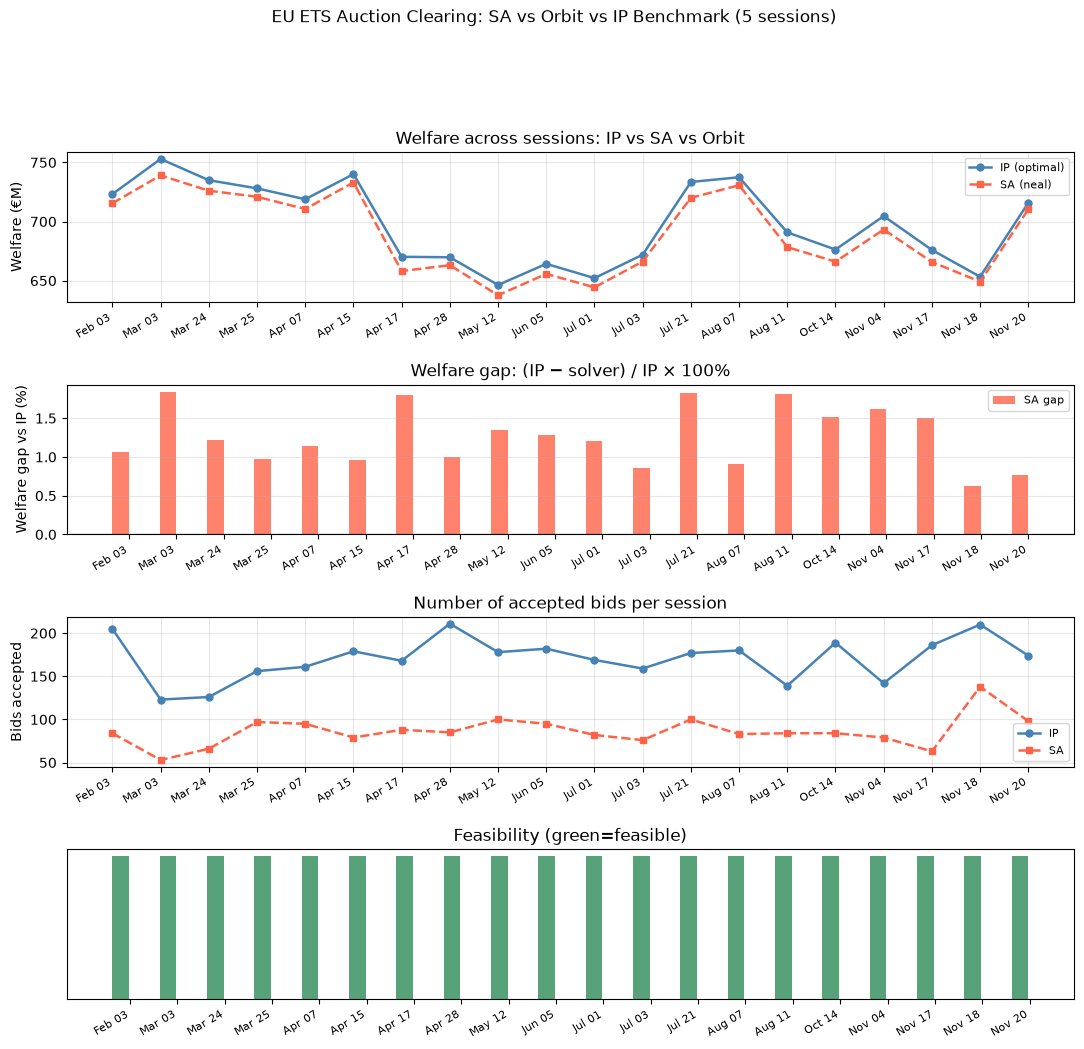

Plot saved to ip_sessions.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

rng_sample   = np.random.default_rng(42)
eua_sessions = df[df['auction_type'] == 'EUA'].reset_index(drop=True)
eua_de_session = df[df['auction_type'] == 'EUA_DE'].iloc[0]
eua_pl_session = df[df['auction_type'] == 'EUA_PL'].iloc[0]
euaa_session = df[df['auction_type'] == 'EUAA'].iloc[0]
sample_idx   = rng_sample.choice(len(eua_sessions), size=20, replace=False)
sample_idx   = np.sort(sample_idx)
sampled      = eua_sessions.iloc[sample_idx].reset_index(drop=True)

print(f"Running {len(sampled)} sessions...")

results = []

for i, (_, session) in enumerate(sampled.iterrows()):
    print(f"\n  Session {i+1}/{len(sampled)}: {session['date'].date()}")

    sess = {
        'EUA':    session,
        'EUA_DE': eua_de_session,
        'EUA_PL': eua_pl_session,
        'EUAA':   euaa_session,
    }

    bids_raw = reconstruct_bids_multisession(sess, package_fraction=0.3, seed=i)

    bids_norm = bids_raw.copy()
    for col in ['quantity', 'value', 'supply', 'package_bonus']:
        bids_norm[col] = bids_norm[col].astype(float)
    for tau in bids_norm['type'].unique():
        mask      = bids_norm['type'] == tau
        S_tau     = bids_norm.loc[mask, 'supply'].iloc[0]
        v_max_tau = bids_norm.loc[mask, 'value'].max()
        bids_norm.loc[mask, 'quantity']      /= S_tau
        bids_norm.loc[mask, 'supply']         = 1.0
        bids_norm.loc[mask, 'value']         /= v_max_tau
        bids_norm.loc[mask, 'package_bonus'] /= v_max_tau

    Q, qparams = build_qubo(bids_raw)
    Q = Q / np.abs(Q).max()

    ip = solve_ip(bids_raw)
    print(f"    IP  feasible={ip['feasible']}  welfare=€{ip['welfare']:,.0f}  accepted={ip['n_accepted']}")

    sa = solve_sa(Q, bids_norm, bids_raw, num_reads=200, num_sweeps=1000)
    if not sa['feasible']:
        sa['x']          = repair_solution(sa['x'], bids_norm, bids_raw)
        sa['welfare']    = bids_raw[sa['x'] == 1]['value'].sum()
        sa['n_accepted'] = int(sa['x'].sum())
        sa['feasible']   = True
    sa_gap = 100 * (1 - sa['welfare'] / ip['welfare'])
    print(f"    SA  feasible={sa['feasible']}  welfare=€{sa['welfare']:,.0f}  gap={sa_gap:.2f}%")

    
    results.append({
        'date':        session['date'],
        'cover_ratio': session['cover_ratio'],
        'ip_welfare':  ip['welfare'],
        'sa_welfare':  sa['welfare'],
        'sa_gap':      sa_gap,
        'sa_feasible': sa['feasible'],
        'ip_accepted': ip['n_accepted'],
        'sa_accepted': sa['n_accepted'],
        'sa_pkg':      sa['pkg_bonus'],
        'ip_pkg':      ip['pkg_bonus'],
    })

results_df = pd.DataFrame(results).sort_values('date').reset_index(drop=True)
print("\nDone.")
print(results_df[['date','sa_gap','ip_welfare','sa_welfare']].to_string())

# --- Plot ---
fig = plt.figure(figsize=(13, 11))
gs  = gridspec.GridSpec(4, 1, hspace=0.55)
dates      = results_df['date']
date_labels = [d.strftime('%b %d') for d in dates]
x_pos      = range(len(results_df))

# Panel 1: Absolute welfare
ax1 = fig.add_subplot(gs[0])
ax1.plot(x_pos, results_df['ip_welfare'] / 1e6, 'o-',
         color='steelblue', label='IP (optimal)', lw=1.8, ms=5)
ax1.plot(x_pos, results_df['sa_welfare'] / 1e6, 's--',
         color='tomato', label='SA (neal)', lw=1.8, ms=5)
ax1.set_ylabel('Welfare (€M)')
ax1.set_title('Welfare across sessions: IP vs SA vs Orbit')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(date_labels, rotation=30, ha='right', fontsize=8)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: Welfare gap vs IP
ax2 = fig.add_subplot(gs[1])
width = 0.35
ax2.bar([p - width/2 for p in x_pos], results_df['sa_gap'],
        width=width, color='tomato', alpha=0.8, label='SA gap')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(date_labels, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Welfare gap vs IP (%)')
ax2.set_title('Welfare gap: (IP − solver) / IP × 100%')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Bids accepted
ax3 = fig.add_subplot(gs[2])
ax3.plot(x_pos, results_df['ip_accepted'], 'o-',
         color='steelblue', label='IP', lw=1.8, ms=5)
ax3.plot(x_pos, results_df['sa_accepted'], 's--',
         color='tomato', label='SA', lw=1.8, ms=5)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(date_labels, rotation=30, ha='right', fontsize=8)
ax3.set_ylabel('Bids accepted')
ax3.set_title('Number of accepted bids per session')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Panel 4: Feasibility strip
ax4 = fig.add_subplot(gs[3])
for j, row in results_df.iterrows():
    ax4.bar(j - 0.2, 1, width=0.35,
            color='seagreen' if row['sa_feasible'] else 'tomato', alpha=0.8)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(date_labels, rotation=30, ha='right', fontsize=8)
ax4.set_yticks([])
ax4.set_title('Feasibility (green=feasible)')

plt.suptitle('EU ETS Auction Clearing: SA vs Orbit vs IP Benchmark (20 sessions)',
             fontsize=12, y=1.01)
plt.savefig('ip_sessions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ip_sessions.png")

In [34]:
#Scaling Benchmark: IP vs SA
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

if __name__ == "__main__":

    # --- Config ---
    scales      = [1, 1.5, 2, 2.5,3,3.5,4,4.5,5,]   # multipliers on base n_bids per type
    SEED        = 42
    SA_READS    = 200
    SA_SWEEPS   = 1000

    bench = []

    for scale in scales:
        # Scale n_bids for every session type
        scaled_sessions = {}
        for tau, sess in sessions.items():
            s = sess.copy()
            s['n_bids'] = int(sess['n_bids'] * scale)
            scaled_sessions[tau] = s

        bids_raw = reconstruct_bids_multisession(scaled_sessions, package_fraction=0.3, seed=SEED)

        # Normalize
        bids_norm = bids_raw.copy()
        for col in ['quantity', 'value', 'supply', 'package_bonus']:
            bids_norm[col] = bids_norm[col].astype(float)
        for tau in bids_norm['type'].unique():
            mask      = bids_norm['type'] == tau
            S_tau     = bids_norm.loc[mask, 'supply'].iloc[0]
            v_max_tau = bids_norm.loc[mask, 'value'].max()
            bids_norm.loc[mask, 'quantity']      /= S_tau
            bids_norm.loc[mask, 'supply']         = 1.0
            bids_norm.loc[mask, 'value']         /= v_max_tau
            bids_norm.loc[mask, 'package_bonus'] /= v_max_tau

        Q, qparams = build_qubo(bids_raw)
        Q = Q / np.abs(Q).max()
        
        n_bids     = len(bids_raw)
        print(f"\n{'='*55}")
        print(f"Scale x{scale}  |  n_bids={n_bids}  |  Q size={n_bids}x{n_bids}")
        print(f"{'='*55}")

        # --- IP ---
        t0 = time.time()
        ip = solve_ip(bids_raw)
        ip_time = time.time() - t0
        print(f"IP    | welfare=€{ip['welfare']:>15,.0f} | feasible={ip['feasible']} | t={ip_time:.2f}s")

        # --- SA ---
        t0 = time.time()
        sa = solve_sa(Q, bids_norm, bids_raw, num_reads=SA_READS, num_sweeps=SA_SWEEPS)
        sa_time = time.time() - t0
        if not sa['feasible']:
            sa['x']         = repair_solution(sa['x'], bids_norm, bids_raw)
            sa['welfare']   = bids_raw[sa['x'] == 1]['value'].sum()
            sa['n_accepted']= int(sa['x'].sum())
            sa['feasible']  = True
        sa_gap = 100 * (1 - sa['welfare'] / ip['welfare'])
        print(f"SA    | welfare=€{sa['welfare']:>15,.0f} | feasible={sa['feasible']} | t={sa_time:.2f}s | gap={sa_gap:.2f}%")

        
        bench.append({
            'scale':       scale,
            'n_bids':      n_bids,
            'ip_welfare':  ip['welfare'],  'ip_time':  ip_time,
            'sa_welfare':  sa['welfare'],  'sa_time':  sa_time,  'sa_gap':  sa_gap,
        })

    bench_df = pd.DataFrame(bench)

    # --- Plots ---
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)
    nb  = bench_df['n_bids']

    colors = {'IP': 'steelblue', 'SA': 'tomato'}
    ms, lw = 6, 1.8

    # Panel 1: Runtime vs n_bids
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(nb, bench_df['ip_time'], 'o-', color=colors['IP'],    label='IP',    lw=lw, ms=ms)
    ax1.plot(nb, bench_df['sa_time'], 's-', color=colors['SA'],    label='SA',    lw=lw, ms=ms)
    ax1.set_xlabel('Number of bids')
    ax1.set_ylabel('Runtime (s)')
    ax1.set_title('Runtime vs Problem Size')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Panel 2: Welfare gap vs n_bids
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(nb, bench_df['sa_gap'], 's-', color=colors['SA'],    label='SA',    lw=lw, ms=ms)
    ax2.axhline(0, color='gray', linestyle='--', lw=1, label='IP (optimal)')
    ax2.set_xlabel('Number of bids')
    ax2.set_ylabel('Welfare gap vs IP (%)')
    ax2.set_title('Solution Quality vs Problem Size')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Panel 3: Absolute welfare
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(nb, bench_df['ip_welfare'] / 1e6, 'o-', color=colors['IP'],    label='IP',    lw=lw, ms=ms)
    ax3.plot(nb, bench_df['sa_welfare'] / 1e6, 's-', color=colors['SA'],    label='SA',    lw=lw, ms=ms)
    ax3.set_xlabel('Number of bids')
    ax3.set_ylabel('Welfare (€M)')
    ax3.set_title('Absolute Welfare vs Problem Size')
    ax3.legend()
    ax3.grid(True, alpha=0.3)


    plt.suptitle('EU ETS Auction Clearing: IP vs SA', fontsize=13, y=1.01)
    plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nPlot saved to benchmark_results.png")
    print(bench_df[['n_bids','ip_time','sa_time','sa_gap']].to_string(index=False))

Per-type C: {'EUA': np.float64(35.25), 'EUA_DE': np.float64(15.45), 'EUA_PL': np.float64(43.89), 'EUAA': np.float64(30.93)}

Scale x1  |  n_bids=321  |  Q size=321x321
IP    | welfare=€    650,559,073 | feasible=True | t=9.57s
SA    | welfare=€    642,550,411 | feasible=True | t=7.54s | gap=1.23%
Per-type C: {'EUA': np.float64(30.3), 'EUA_DE': np.float64(33.72), 'EUA_PL': np.float64(22.01), 'EUAA': np.float64(28.43)}

Scale x2  |  n_bids=642  |  Q size=642x642
IP    | welfare=€    645,065,795 | feasible=True | t=142.73s
SA    | welfare=€    639,410,828 | feasible=True | t=28.68s | gap=0.88%
Per-type C: {'EUA': np.float64(70.7), 'EUA_DE': np.float64(27.24), 'EUA_PL': np.float64(54.04), 'EUAA': np.float64(67.75)}

Scale x4  |  n_bids=1284  |  Q size=1284x1284
IP    | welfare=€    637,784,058 | feasible=True | t=883.20s
SA    | welfare=€    631,988,181 | feasible=True | t=97.69s | gap=0.91%
Per-type C: {'EUA': np.float64(135.54), 'EUA_DE': np.float64(85.16), 'EUA_PL': np.float64(96.71), '

KeyboardInterrupt: 